# Lab 9: Pick and Place with MoveIt (worked solutions)

Companion to `pdfs/Pick_And_Place-2.pdf` (September version) and the packages in `pp_moveit_ws/src`
(`mycobot_vision/vision.py`, `mycobot_brain/brain.py`, `mycobot_interfaces`, `mycobot_controller`).
This lab has **no notebook template**: it is a project. Part 1 (explore the running system) needs the robot;
then **two of five tasks** are chosen and documented. Which two is a group decision (`gameplan.md` §8).

**How to read this notebook.** The code cells are the functions you would put into `vision.py` / `brain.py`, in the order of the PDF's
tasks. The synthetic images used to test them (virtual camera, coloured cubes, cylinders) are in `lab9_synthetic.py` and are not part of the
solution. After each task a **Where this goes** note says which lines of which file the code replaces. **How to run the real system (which
machine runs which node, which files each machine needs, the values you can change):** `Lab8_Lab9_run_guide.md` in this folder.

| # | Task | Needs the lab? | What this notebook contains |
|---|---|---|---|
| 0 | Explore the existing system | yes (robot, camera) | the **data flow** to trace, a checklist, and problems found by **reading the code** |
| A | Camera calibration with ArUco markers | camera, markers | complete pipeline on a **synthetic camera** (render → detect → `solvePnP` → pixel-to-robot → validation) |
| B | Robust HSV masking | camera images | original vs improved detector on synthetic frames, with numbers |
| C | Interactive HSV threshold calibration | one image | tested functions + the GUI program `solutions/hsv_calibrator.py` |
| D | Object shape detection | camera images | features and classifier on synthetic masks, with `unknown` |
| E | Extension of the object interface | ROS + MoveIt | service definition, selection logic, IDs, menu loop, MoveIt geometry |

**What is real and what is not.** The algorithms are complete and tested, but on **synthetic data**, because the real camera images,
markers and cubes are only available in the lab. Anything that must be measured on the real setup (intrinsics, marker positions,
thresholds under your lighting, validation errors) is marked and has to be redone there. The deliverables of the PDF (report, annotated
images, tables) come from the real experiments; here you get the method and code, and a reference for what "good" looks like.
Nothing here talks to the robot or ROS.


## Setup

In [1]:
%matplotlib widget
import os, sys, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt

import lab9_synthetic as syn      # solutions/lab9_synthetic.py: synthetic images with known ground truth (test bench only)
warnings.filterwarnings('ignore', category=DeprecationWarning)
np.set_printoptions(precision=4, suppress=True)
print('OpenCV', cv2.__version__, ' NumPy', np.__version__)

OpenCV 4.6.0  NumPy 1.26.4


---
# Part 0: Explore the existing system
## The software architecture and one pick-and-place, step by step
| node | role | interfaces used |
|---|---|---|
| **Camera** | publishes the USB camera image at 10 Hz | topic `camera/image` (`sensor_msgs/Image`) |
| **Vision** (`vision.py`) | HSV masks per colour, finds squares, maps pixel → robot, keeps `detected_cubes` | subscribes `camera/image`; **service server** `/cube_coordinates` (`GetCubeCoords`) |
| **Brain** (`brain.py`) | text menu, sequences (sort, stack), coordinates everything | **service client** `/cube_coordinates`; publishes `/collision_object`, `/attached_collision_object`, `/pump_controller`; **action client** `move_action` (MoveGroup); **service client** `/compute_cartesian_path`; **action client** `/arm_group_controller/follow_joint_trajectory` |
| **MoveIt** (`move_group`) | plans collision-free motions in a planning scene | subscribes the two collision topics; action server `move_action`; service server `compute_cartesian_path`; action *client* of the controller's `follow_joint_trajectory` (it executes the trajectories it planned) |
| **Controller** (`controller.py`) | hardware interface to the myCobot 280pi | action server `follow_joint_trajectory` (two clients: MoveIt and Brain); publishes joint states (20 Hz); subscribes `/pump_controller` |

**One sorting operation (menu mode 2), in order**
1. `Brain.choose_pick()` deletes and re-creates the four colour cubes in the planning scene: `spawn_cube(color)` asks Vision for the coordinates.
2. **Vision → Brain:** `get_cube_coords(color)` → service `/cube_coordinates`; Vision answers from the last image with `[x, y, z, rx, ry, rz]` (or six 1.0 if the cube is not detected).
3. Brain publishes a `CollisionObject` (a 4 cm box with id = colour) on `/collision_object` → MoveIt's planning scene; the cube is *attached to the table* (`/attached_collision_object`) so it does not collide with other cubes.
4. `pick(color)`: request the coordinates again; **hover pose** 10 cm above → action `move_action` (MoveIt plans and executes a free-space trajectory: pose goal with 1 mm position tolerance).
5. **Descend:** service `/compute_cartesian_path` (straight line) → Brain sends the returned trajectory to `follow_joint_trajectory` (MoveIt has no action for executing Cartesian paths).
6. **Pump on:** message `"on"` on `/pump_controller` → Controller switches the GPIO; the cube is re-attached from the table to `pump_head` in the planning scene.
7. **Retract:** Cartesian path up; then `go_home()` (pose goal).
8. `choose_drop(color)`: user picks a bin A–D; hover pose over the bin via `move_action`; pump off (`"off"`); detach/attach in the scene; home.

Trajectory *planning* and *execution* are separate: MoveIt plans (and executes, for `move_action`), the Brain executes its own Cartesian paths, the Controller is the only node that talks to the hardware.

## What to observe and document (report checklist)
- Initial cube positions, menu selections, bins, result (success/failure and why).
- At least **two limitations or surprises**. The code reading below gives candidates to look for; find out which ones you can also *see*.
- A diagram or the numbered list above, adapted to what you saw (node names from `ros2 node list`, `rqt_graph`).
- Commands that help: `ros2 node list`, `ros2 topic list -t`, `ros2 service list -t`, `ros2 action list -t`, `ros2 interface show mycobot_interfaces/srv/GetCubeCoords`, `rqt_graph`.

**Safety:** first motions under supervision, workspace clear, simulate first (RViz simulation **replaces** the Controller: never run both).

## Problems found by reading the code
These are facts from `vision.py` / `brain.py`; whether they hurt in practice has to be shown in your experiments.

| # | where | issue | consequence / relation to a task |
|---|---|---|---|
| 1 | `vision.send_cube_coords` | pixel → robot uses fixed constants for an **old camera pose** (`(cy-55)/280*0.15+0.08`, `(cx-185)/280*0.15-0.075`) | systematic position error if the camera moved: Task A |
| 2 | same | returns `z = 0.01` for every cube, whatever the reference point; `spawn_cube` uses the same value as the **centre** of a 4 cm box (which would then extend 1 cm below the table) | grasp height / collision box inconsistent: Task A step 5 |
| 3 | same | the image angle of `cv2.minAreaRect` is converted straight to radians and used as yaw in the robot frame | wrong yaw unless the camera axes match the robot axes; Task A step 5 |
| 4 | `vision.img_callback` | `detected_cubes` is a **persistent dictionary**: a colour stays in it after the cube was removed | stale detections, the robot picks nothing: Task B step 4 |
| 5 | `send_cube_coords` / `Brain.get_cube_coords` | "not detected" is encoded as the magic value `[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]` | a real coordinate could equal it; fragile: Task E |
| 6 | `colors["red"]` | second hue interval `(170 … 200)`, but OpenCV hue only goes to **179** | harmless here (values above 179 do not exist) but wrong: Task B step 1 |
| 7 | `colors` | fixed thresholds, e.g. blue `S ≥ 200, V ≥ 200`, others `V ≥ 100` | fail in dim light or shadow: Tasks B, C |
| 8 | `vision.img_callback` | one cube per colour; the "best" is the most square one | two same-colour objects impossible: Tasks D, E |
| 9 | `Brain.spawn_cube`, ids | collision-object id = **colour**; box always 4 × 4 × 4 cm | cannot represent cylinders or two red objects: Task E |
| 10 | `Brain.send_cartesian_path` | the failure branch logs `result.error_code.val`, but the `FollowJointTrajectory` result's `error_code` is an **int**, so a failed execution raises `AttributeError` instead of being reported | crash exactly when a trajectory fails: report it as an unexpected behaviour |
| 11 | `Brain.choose_pick`, `choose_drop`, `control_menu` | menus call themselves recursively ("exit" and every loop add a stack frame) | never returns; Task E step 6 |
| 12 | `Brain.stack_cubes` | `cubes_stacked = 2` hard-coded, fixed order red → green → blue, 4 cm per cube | limited flexibility |
| 13 | `vision.__init__` | `cv2.namedWindow` in the constructor | fails on a machine without a display |
| 14 | `vision.img_callback` | `np.int0` (removed in NumPy 2) | breaks if the venv gets NumPy 2 (numpy<2 is pinned for ROS) |
| 15 | `Brain.stack_cubes` / `choose_pick` → `Brain.rejoice()`, `Controller.rejoice` | after **every** sort or stack run the brain publishes `True` on `/rejoice`; the controller then sends the joint angles **`[0,0,0,0,0,0]`** (speed 40), `[0,-60,15,-45,0,0]` (30), `[0,0,0,0,0,0]` (50) with fixed sleeps | the arm swings to the all-zero pose, automatically, with no check of the workspace: be ready, or remove the two `self.rejoice()` calls in your copy of `brain.py` |
| 16 | `Brain.send_goal_pose` | position tolerance a **1 mm sphere**, orientation tolerance 0.01 rad per axis, 10 attempts, 5 s planning time, velocity and acceleration scaling 1.0 | tight constraints: planning fails for poses at the edge of the workspace ("failed trajectories" to look for) |
| 17 | `Brain.send_cartesian_path` | the request header frame is `"world"`, all other poses use `"g_base"` | harmless only if `world` and `g_base` coincide in the URDF: check when a straight-line path ends in the wrong place |


---
# Task A: Camera-to-robot calibration with ArUco markers
**Goal:** replace the fixed pixel mapping by a calibrated transformation. Steps: (1) intrinsics, (2) marker geometry, (3) extrinsics with
`solvePnP`, (4) pixel → robot by intersecting a camera ray with a plane, (5) review returned pose (height, yaw), (6) validate.

## Synthetic test bench
Because the real camera is not here, a **virtual camera** with a known pose looks at two ArUco markers. Everything estimated below is
compared with this known truth: you learn what accuracy the method can reach, and what breaks it. In the lab the image comes from the
camera instead.

Frames: **B** = robot base (x forward, y left, z up). **C** = camera (x right in the image, y down, z along the viewing direction).
The camera hangs above the workspace looking down, exactly like in Lab 8: `R_BC` maps camera axes to base axes, `t_BC` is the camera origin in B.

In [2]:
# Intrinsics: the values of the Lab 8 vision node (stand-in; they must be re-measured for the camera you use, see step 1)
K_cam = np.array([[756.78, 0.0, 327.93],
                  [0.0, 751.59, 224.30],
                  [0.0, 0.0, 1.0]])
dist = np.zeros(5)                 # synthetic camera without lens distortion (real d = [k1, k2, p1, p2, k3])
W, H = 640, 480

# TRUE camera pose (unknown in reality): camera 0.39 m above the base plane, looking down
R_BC_true = np.array([[0, 1, 0],
                      [1, 0, 0],
                      [0, 0, -1]], dtype=float)      # camera x -> base y, camera y -> base x, camera z -> -base z
t_BC_true = np.array([0.17, 0.0, 0.39])
R_CB_true = R_BC_true.T
t_CB_true = -R_CB_true @ t_BC_true
rvec_CB_true, _ = cv2.Rodrigues(R_CB_true)

def project_B(points_B, rvec=rvec_CB_true, tvec=t_CB_true):
    """Pixel coordinates of 3D points given in the base frame (the camera model: K [R|t])."""
    pix, _ = cv2.projectPoints(np.asarray(points_B, float).reshape(-1, 3), rvec, tvec, K_cam, dist)
    return pix.reshape(-1, 2)

print('true camera position in B:', t_BC_true)

true camera position in B: [0.17 0.   0.39]


**How it works**
- The **camera model** (pinhole): a point $p_C = R_{CB}p_B + t_{CB}$ in the camera frame appears at the pixel
  $u = f_x\,x/z + c_x,\; v = f_y\,y/z + c_y$, i.e. $s\,[u,v,1]^T = K\,p_C$ with the intrinsic matrix $K$. `cv2.projectPoints` does exactly this (plus distortion).
- The camera pose is described in two ways: $(R_{CB}, t_{CB})$ maps **base → camera** ($p_C = R_{CB}p_B + t_{CB}$), which is what `solvePnP` returns;
  its inverse $R_{BC} = R_{CB}^T,\; t_{BC} = -R_{CB}^Tt_{CB}$ is the **camera pose in the base frame**, what you want to use (and to compare with the measured height).
- $R_{BC}$ as above is the same rotation as the vision node of Lab 8 (`R_base_cam`): the camera looks along $-z_B$.

## Step 1: Camera intrinsics and distortion
**Method (real camera):** photograph a chessboard (e.g. 9×6 inner corners, known square size) in 15–20 different poses at the resolution used by `vision.py`, then
```python
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(object_points, image_points, (width, height), None, None)
```
where `object_points` are the 3D board corners (z = 0) and `image_points` come from `cv2.findChessboardCorners` + `cv2.cornerSubPix`. The RMS reprojection error `ret` should be below ~0.5 px.
The result is $K$ (focal lengths $f_x, f_y$, principal point $c_x, c_y$) and `dist` = $[k_1, k_2, p_1, p_2, k_3]$ (radial and tangential lens distortion).

**How distortion is handled:** distortion bends straight lines; the pinhole equations only hold for **undistorted** pixels. Every pixel that is used for geometry
(marker corners, cube centres) must first be undistorted: `cv2.undistortPoints(pts, K, dist)` returns **normalised** coordinates $(x/z, y/z)$ directly,
which is exactly what the ray computation in step 4 needs. `solvePnP` and `projectPoints` take `dist` themselves. Using the wrong or no distortion coefficients shifts points near the image border by several pixels.
Important: `K` and `dist` are only valid for **the resolution they were calibrated at**; if `vision.py` changes the image size, scale $f$ and $c$ accordingly.

## Step 2: Marker geometry in the base frame
Each marker is a square of side $s$, lying flat on the plane $z_B = 0$ (state the real height if different), at a known centre $(x_c, y_c)$ and rotation (yaw). ArUco returns its four corners in a **fixed order**:
starting at the marker's own **top-left** corner and going **clockwise** (as seen in the image, i.e. TL, TR, BR, BL of the printed pattern). The 3D corners must be listed in the same order, so the geometry is defined in the *marker frame* (x to the right of the printed pattern, y up) and transformed:

$$ p_B = R_z(\psi)\,p_M + [x_c, y_c, 0]^T,\qquad p_M \in \{(-\tfrac s2,\tfrac s2),(\tfrac s2,\tfrac s2),(\tfrac s2,-\tfrac s2),(-\tfrac s2,-\tfrac s2)\} $$

The association marker ↔ geometry is by the **ArUco ID** (a dictionary lookup), so the order in which the detector returns markers does not matter.

In [3]:
def marker_corners_B(center_xy, yaw, side):
    """Corners TL, TR, BR, BL of a marker lying in the plane z = 0 (marker frame: x right, y up), in the base frame."""
    h = side / 2.0
    corners_M = np.array([[-h,  h], [h,  h], [h, -h], [-h, -h]])
    c, s = np.cos(yaw), np.sin(yaw)
    R = np.array([[c, -s], [s, c]])
    xy = corners_M @ R.T + np.asarray(center_xy)
    return np.column_stack([xy, np.zeros(4)])

# geometry known from the physical placement (measure it with a ruler in the lab!): id -> (centre x, y in m, yaw in rad, side in m)
MARKERS = {0: ((0.10, -0.06), 0.3, 0.05),
           1: ((0.20,  0.06), -0.5, 0.05)}
MARKER_GEOMETRY = {mid: marker_corners_B(c, yaw, side) for mid, (c, yaw, side) in MARKERS.items()}
for mid, corners in MARKER_GEOMETRY.items():
    print('marker', mid, 'corners in B (TL, TR, BR, BL):\n', corners[:, :2].round(4))

marker 0 corners in B (TL, TR, BR, BL):
 [[ 0.0687 -0.0435]
 [ 0.1165 -0.0287]
 [ 0.1313 -0.0765]
 [ 0.0835 -0.0913]]
marker 1 corners in B (TL, TR, BR, BL):
 [[0.19   0.0939]
 [0.2339 0.07  ]
 [0.21   0.0261]
 [0.1661 0.05  ]]


**How it works**
- `corners_M @ R.T + center`: rotate each row vector by the yaw and shift (the matrix form of $R\,p$ for many points).
- A dictionary `MARKER_GEOMETRY[id]` gives the 4×3 corner array for each ID.
- The corner order (TL, TR, BR, BL) must match the detector's order, or `solvePnP` gets wrong correspondences and returns a mirrored or rotated pose.
  Also **use the corners, not the centres**: two centre points give 2 correspondences, 4 numbers; the pose has 6 unknowns. Eight corners give 16 numbers.

### Rendering the synthetic image (test bench only)
Markers are drawn with `cv2.aruco.drawMarker`, padded with a white margin (**ArUco needs a white quiet zone**: with too thin a margin the detector finds candidate squares but
identifies no marker) and warped to the pixel positions given by the true camera model. Noise and blur make it realistic.

In [4]:
aruco = cv2.aruco
ARUCO_DICT = aruco.getPredefinedDictionary(aruco.DICT_4X4_50)

image = syn.render_markers(MARKERS, ARUCO_DICT, project_B, (W, H), seed=0)     # in the lab: the camera image, converted to gray
print(image.shape, image.dtype)

(480, 640) uint8


## Step 3: Estimate the camera extrinsics
Detect both markers, collect the **eight** corner correspondences (3D corner in B ↔ detected pixel), and solve the Perspective-n-Point problem:
$p_C = R_{CB}p_B + t_{CB}$. Then invert to get the camera pose in the base frame. **Enable sub-pixel corner refinement**: it is the biggest single accuracy factor (see the comparison below).

In [5]:
def detect_markers(gray, subpixel=True):
    params = aruco.DetectorParameters_create()
    if subpixel:
        params.cornerRefinementMethod = aruco.CORNER_REFINE_SUBPIX
    corners, ids, _ = aruco.detectMarkers(gray, ARUCO_DICT, parameters=params)
    return {} if ids is None else {int(i): c.reshape(4, 2) for c, i in zip(corners, ids.ravel())}

def estimate_camera_pose(gray, subpixel=True):
    """Camera pose in the base frame from the markers in `gray`. Returns (R_BC, t_BC, reproj_px) or None."""
    detected = detect_markers(gray, subpixel)
    missing = [mid for mid in MARKER_GEOMETRY if mid not in detected]
    if missing:                                                      # a marker is missing: do NOT produce a pose
        print('calibration refused, marker(s) not found:', missing)
        return None
    ids = sorted(MARKER_GEOMETRY)
    object_points = np.vstack([MARKER_GEOMETRY[i] for i in ids])     # 8 x 3
    image_points = np.vstack([detected[i] for i in ids])             # 8 x 2
    ok, rvec, tvec = cv2.solvePnP(object_points, image_points, K_cam, dist, flags=cv2.SOLVEPNP_ITERATIVE)
    if not ok:
        return None
    R_CB, _ = cv2.Rodrigues(rvec)
    R_BC, t_BC = R_CB.T, -R_CB.T @ tvec.ravel()                      # invert the transform
    reproj, _ = cv2.projectPoints(object_points, rvec, tvec, K_cam, dist)
    return R_BC, t_BC, np.linalg.norm(reproj.reshape(-1, 2) - image_points, axis=1)

result = estimate_camera_pose(image)
R_BC_est, t_BC_est, reproj = result
print('estimated camera position in B (m):', t_BC_est, '  true:', t_BC_true)
print('camera looks along (B):', R_BC_est[:, 2].round(3), '  (true:', R_BC_true[:, 2], ')')
print('estimated height %.4f m, measured height h = %.4f m -> difference %.1f mm' % (t_BC_est[2], t_BC_true[2], (t_BC_est[2] - t_BC_true[2]) * 1000))
print('marker-corner reprojection error: mean %.2f px, max %.2f px' % (reproj.mean(), reproj.max()))

estimated camera position in B (m): [0.1693 0.0014 0.3899]   true: [0.17 0.   0.39]
camera looks along (B): [ 0.002 -0.004 -1.   ]   (true: [ 0.  0. -1.] )
estimated height 0.3899 m, measured height h = 0.3900 m -> difference -0.1 mm
marker-corner reprojection error: mean 0.12 px, max 0.22 px


**How it works**
- `cv2.aruco.detectMarkers` returns for each marker a 4×2 array of corner pixels and its ID; the result is turned into a dictionary `id → corners`.
- `cv2.solvePnP(object_points, image_points, K, dist)` finds the pose $(r, t)$ (rotation as a Rodrigues vector) that best maps the 3D points into the
  measured pixels (least squares on the reprojection error). Planar targets (all points at $z=0$) are special: there can be a **second, mirrored solution**
  (the "pose ambiguity"). That is why the step says: *select a pose consistent with the physical camera placement*. Test: the camera must be **above** the plane
  (positive height) and look **down** (the viewing axis $R_{BC}[:,2]$ points to $-z_B$), and the height must agree with the measured value `h`.
  The estimated height (0.390 m) matches within a millimetre here.
- `cv2.Rodrigues(rvec)` converts between the rotation vector and the 3×3 matrix. **Inversion:** $R_{BC} = R_{CB}^T$, $t_{BC} = -R_{CB}^Tt_{CB}$ (the rule for rigid transforms from Lab 1).
- **If a marker is missing** the function refuses (returns `None`, prints a message). Options for the node: keep the last valid calibration and log a warning, or
  publish "not calibrated" and refuse to send coordinates. With one marker only (4 corners of a small square) the pose is poorly constrained.
- **Reprojection error** = pixel distance between the detected corners and the corners projected with the estimated pose; a small value shows the model fits the
  data, not necessarily that the pose is accurate (see below).

**Why sub-pixel refinement matters (same image, 8 noisy images):**

```python
def camera_positions(subpixel, n=8):
    out = []
    for seed in range(n):
        r = estimate_camera_pose(syn.render_markers(MARKERS, ARUCO_DICT, project_B, (W, H), seed=seed), subpixel=subpixel)
        if r is not None:
            out.append(r[1])
    return np.array(out)

for flag in (False, True):
    p = camera_positions(flag)
    print(f'subpixel={flag!s:5}: mean position error (mm) {np.round((p.mean(0) - t_BC_true) * 1000, 1)}   scatter over images (mm) {np.round(p.std(0) * 1000, 1)}')
```

Output:
```text
subpixel=False: mean position error (mm) [11.2 -8.3 -0.8]   scatter over images (mm) [2.9 1.9 0.1]
subpixel=True : mean position error (mm) [-0.7  1.5 -0.1]   scatter over images (mm) [0.1 0.1 0. ]
```


- Without sub-pixel refinement the corners are only accurate to about a pixel, and the camera position is off by ~10 mm in x and y (the height is much better determined,
  because it follows from the apparent size of the markers). With `CORNER_REFINE_SUBPIX` the error drops to about 1 mm.
- **Consistency check (last step of the task):** repeat the calibration with several images (the scatter column) and see whether the estimates agree. Large scatter means noisy corners
  or too small/too close markers. Use bigger markers, spread them out over the workspace, and average several calibrations.

## Step 4: Pixel → robot coordinates (ray – plane intersection)
A pixel defines a **ray** through the camera centre. For an undistorted pixel $(u,v)$ the ray direction in the camera frame is $r_C = K^{-1}[u,v,1]^T = [x_n, y_n, 1]^T$
(the normalised coordinates). In the base frame the ray is $p_B(\lambda) = t_{BC} + \lambda\,R_{BC}\,r_C$. Intersect it with the plane $z_B = z_{object}$ that contains the visible top surface:

$$ \lambda = \frac{z_{object} - t_{BC,z}}{(R_{BC}\,r_C)_z},\qquad p_B = t_{BC} + \lambda R_{BC}r_C $$

**Which plane?** A single camera cannot measure depth. The height of the **top face** of the cube in the base frame is used: 0.04 m for a cube lying on the table (0.04 m tall). Assuming
$z=0$ (the table or marker plane) would put the top face's image point onto the wrong 3D point (parallax): the error grows with the distance from the point straight below the camera.

In [7]:
def pixel_to_base(u, v, R_BC, t_BC, z_object, workspace=((0.05, 0.25), (-0.10, 0.10))):
    """Robot-base position (x, y, z) of an image point (u, v) that lies on the plane z = z_object, or None."""
    x_n = cv2.undistortPoints(np.array([[[u, v]]], float), K_cam, dist).reshape(2)     # normalised, distortion removed
    ray_B = R_BC @ np.array([x_n[0], x_n[1], 1.0])                                     # ray direction in the base frame
    if abs(ray_B[2]) < 1e-9:
        return None                                                                    # ray parallel to the plane
    lam = (z_object - t_BC[2]) / ray_B[2]
    if lam <= 0:                                                                       # intersection behind the camera
        return None
    p = t_BC + lam * ray_B
    (x0, x1), (y0, y1) = workspace
    if not (x0 <= p[0] <= x1 and y0 <= p[1] <= y1):                                    # outside the workspace: reject
        return None
    return p

**How it works**
- `cv2.undistortPoints(pts, K, dist)` (input shape `(N, 1, 2)`) removes lens distortion and returns the **normalised** coordinates $(x/z, y/z)$: the ray direction with $z = 1$. `.reshape(2)` flattens the result.
- `ray_B = R_BC @ [x_n, y_n, 1]`; solving $t_{z} + \lambda\,\text{ray}_z = z_{object}$ gives $\lambda$; **$\lambda \le 0$** means the plane lies behind the camera: reject.
- The final check keeps only points inside the workspace rectangle (the same idea as the workspace limits of Lab 8).
- The demonstration: with the right plane the answer is (0.150, 0.030, 0.040); with the table plane the result is displaced by several millimetres. The last call shows both rejection paths (`None`).

**Example: the demonstration (right plane, wrong plane, rejected points)**

```python
# a cube whose top face (z = 0.04) is centred at (0.15, 0.03)
top = np.array([[0.15, 0.03, 0.04]])
uv = project_B(top)[0]
print('pixel of the cube top:', uv.round(1))
print('with the estimated pose and the correct plane z = 0.04:', pixel_to_base(*uv, R_BC_est, t_BC_est, 0.04).round(4))
print('wrongly assuming the table plane z = 0            :', pixel_to_base(*uv, R_BC_est, t_BC_est, 0.0).round(4))
print('outside the workspace / behind the camera         :', pixel_to_base(5, 5, R_BC_est, t_BC_est, 0.04), pixel_to_base(*uv, R_BC_est, t_BC_est, 0.6))
```

Output:
```text
pixel of the cube top: [392.8 181.4]
with the estimated pose and the correct plane z = 0.04: [0.15   0.0301 0.04  ]
wrongly assuming the table plane z = 0            : [0.1477 0.0334 0.    ]
outside the workspace / behind the camera         : None None
```


## Step 5: Review the returned pose (height and yaw)
**Height.** `send_cube_coords` returns the constant `z = 0.01`. Is that wrong? It is part of a **tuned chain** in `brain.py`:
`pick()` hovers at `z + 0.10` and lowers by `0.05` (so the pump head ends at `z + 0.05 = 0.06` m); `place()` hovers at `z + 0.04·n + 0.06` and lowers by `0.05`.
With the top face of a cube at 0.04 m, the pump head ends **2 cm above the top face**: that is the offset between the `pump_head` frame and the cup's contact point. So `0.01 + 0.05 = 0.04 + 0.02`: the constant
works because it is **0.03 m below the top face**, and the brain's constants silently depend on it. Two consequences:
- If you return the true top-face height (0.04), the pump goes 3 cm too high unless you change `pick()` (use hover `+0.07`, lower `-0.05` → `+0.02` above the top face) and `place()` accordingly.
  Either keep returning `z_top − 0.03` and document it, or change both ends together. **Never change only one side.**
- `spawn_cube` uses the same `z = 0.01` as the **centre** of a 4 cm box, so the box in the planning scene spans −0.01…0.03 m instead of 0…0.04 m: 1 cm too low. It is a modelling error that the planner never notices, because the cube is attached to `env_table`.

A consistent, explicit convention (frame `g_base`, metres, reference point = top-face centre) is what the deliverable asks for: state it next to the calibration parameters.

**Yaw.** `cv2.minAreaRect` gives an angle in the **image** frame (rotation about the camera axis), not about the robot z-axis; its numeric range and convention also changed between OpenCV
versions. To get the yaw in B, transform the *direction* of the rectangle edge like a point: take two pixels along the edge, map both with `pixel_to_base`, and use `atan2` of the difference.
A cube is symmetric under 90° turns, so wrap the result to $(-45°, 45°]$.


In [9]:
def image_angle_to_base_yaw(center_uv, angle_deg, R_BC, t_BC, z_object, step_px=30.0):
    """Yaw of a square about the base z-axis from the image angle of its edge (deg), wrapped to (-45, 45] degrees."""
    a = np.radians(angle_deg)
    p0 = pixel_to_base(*center_uv, R_BC, t_BC, z_object)
    p1 = pixel_to_base(center_uv[0] + step_px * np.cos(a), center_uv[1] + step_px * np.sin(a), R_BC, t_BC, z_object)
    yaw = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
    return (yaw + 45.0) % 90.0 - 45.0

- The image angle of the edge is 70° while the true yaw is 20°: with this camera the image axes are turned by 90° relative to the robot axes ($x_C \to y_B$), so the raw
  `minAreaRect` angle would rotate the pump (or the box in the planning scene) the wrong way. Mapping the edge direction through the calibrated geometry returns the correct 20°, which
  would also handle a camera that is rotated by any other angle, or mounted at a tilt.

**Example: a cube with a known yaw of 20 degrees**

```python
yaw_true = np.radians(20.0)
half = 0.02
corners_top = np.array([[np.cos(yaw_true) * x - np.sin(yaw_true) * y + 0.15, np.sin(yaw_true) * x + np.cos(yaw_true) * y + 0.03, 0.04]
                        for x, y in ((-half, -half), (half, -half), (half, half), (-half, half))])
cpix = project_B(corners_top)
edge = cpix[1] - cpix[0]
angle_img = np.degrees(np.arctan2(edge[1], edge[0]))
center_pix = cpix.mean(axis=0)
print('image angle of the edge: %.1f deg   (naive use as yaw would be wrong)' % angle_img)
print('yaw in the robot frame : %.1f deg   (true: 20.0)' % image_angle_to_base_yaw(center_pix, angle_img, R_BC_est, t_BC_est, 0.04))
```

Output:
```text
image angle of the edge: 69.9 deg   (naive use as yaw would be wrong)
yaw in the robot frame : 20.0 deg   (true: 20.0)
```


## Step 6: Validation
1. **Reprojection error** of the eight marker corners (mean and max, pixels): printed in step 3.
2. **Independent positions:** place an object at several measured workspace positions, including near the edges, and compare the returned robot coordinates with the ruler values. Here the "measurements" are the true positions
   plus 0.5 px of detection noise.
3. **Repeatability:** calibrate from several images and check the spread.

In [11]:
rng = np.random.default_rng(5)
validation_xy = np.array([[0.08, -0.07], [0.08, 0.07], [0.15, 0.00], [0.22, -0.07], [0.22, 0.07], [0.12, 0.04], [0.18, -0.03]])   # incl. workspace edges
errors = []
print(f"{'true x,y [m]':>16s} {'returned x,y [m]':>18s} {'error [mm]':>11s}")
for x, y in validation_xy:
    uv = project_B(np.array([[x, y, 0.04]]))[0] + rng.normal(0, 0.5, 2)        # the detected pixel: truth + noise
    p = pixel_to_base(*uv, R_BC_est, t_BC_est, 0.04)
    e = np.linalg.norm(p[:2] - [x, y]) * 1000
    errors.append(e)
    print(f'{x:7.3f},{y:7.3f}   {p[0]:8.4f},{p[1]:8.4f}   {e:9.2f}')
print('position error: mean %.2f mm, max %.2f mm' % (np.mean(errors), np.max(errors)))
print('camera reprojection: mean %.2f px, max %.2f px' % (reproj.mean(), reproj.max()))

    true x,y [m]   returned x,y [m]  error [mm]


  0.080, -0.070     0.0796, -0.0700        0.37
  0.080,  0.070     0.0802,  0.0700        0.16
  0.150,  0.000     0.1500,  0.0004        0.42
  0.220, -0.070     0.2198, -0.0700        0.21
  0.220,  0.070     0.2203,  0.0703        0.40
  0.120,  0.040     0.1197,  0.0402        0.35
  0.180, -0.030     0.1803, -0.0301        0.32
position error: mean 0.32 mm, max 0.42 mm
camera reprojection: mean 0.12 px, max 0.22 px


**How to read this / what to report**
- With sub-pixel corners the reprojection error is ~0.1 px and the errors at independent positions are below ~1 mm (this includes the 0.5 px detection noise). On the real robot expect **larger** errors (typically
  2–5 mm): marker positions measured by hand, lens distortion residuals, the camera not exactly at the assumed height, and the robot's own accuracy (±0.5 mm).
- **Using the wrong plane costs up to 13 mm**: as large as the pump's tolerance for a 4 cm cube. The height convention (step 5) is as important as the calibration itself.
- **Deliverables for the real experiment:** the updated `vision.py`; the calibration parameters with explicit frame and unit conventions (`K`, `dist`, `R_BC`, `t_BC`, plane heights, metres, `g_base`); an annotated image
  (`cv2.aruco.drawDetectedMarkers` and the reprojected corners drawn as circles); a table like the one above with **measured** ground truth. Repeat the calibration with several images (repeatability).

**Example: what the wrong plane costs (same validation points, plane z = 0)**

```python
wrong = [np.linalg.norm(pixel_to_base(*project_B(np.array([[x, y, 0.04]]))[0], R_BC_est, t_BC_est, 0.0)[:2] - [x, y]) * 1000 for x, y in validation_xy]
print('assuming z = 0 instead of the top-face height: mean %.1f mm, max %.1f mm' % (np.mean(wrong), np.max(wrong)))
```

Output:
```text
assuming z = 0 instead of the top-face height: mean 8.4 mm, max 13.0 mm
```


**Where this goes: `mycobot_vision/vision.py`**

| in this notebook | in `vision.py` |
|---|---|
| `K_cam`, `dist` | new attributes set in `Vision.__init__`, measured with `cv2.calibrateCamera` at the resolution of `camera/image` |
| `MARKER_GEOMETRY`, `detect_markers`, `estimate_camera_pose` | new method `Vision.calibrate(self, gray)`, called from `img_callback` until it succeeds (and again on a key press); stores `self.R_BC`, `self.t_BC` |
| `pixel_to_base`, `image_angle_to_base_yaw` | replace the lines `px_norm = ...`, `py_norm = ...`, `rotz = rot/180 * 3.14159` in `send_cube_coords` |

```python
# send_cube_coords(): instead of the fixed linear mapping
cx, cy, angle = self.detected_cubes[color]
p = pixel_to_base(cx, cy, self.R_BC, self.t_BC, z_object=0.04) if self.R_BC is not None else None   # 0.04 m = top face of a cube
if p is None:
    response.coords = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]                 # the existing "not detected" answer (Task E replaces it by a flag)
else:
    yaw = np.radians(image_angle_to_base_yaw((cx, cy), angle, self.R_BC, self.t_BC, 0.04))
    response.coords = [p[0], p[1], Z_REPORTED, 0.0, 0.0, yaw]        # Z_REPORTED: see Step 5, keep 0.01 unless pick()/place() change too
```
Order of work in the lab: measure the marker positions with a ruler → photograph a chessboard for `K`, `dist` → run the calibration and compare the estimated height with the measured camera height → only then touch `send_cube_coords`.


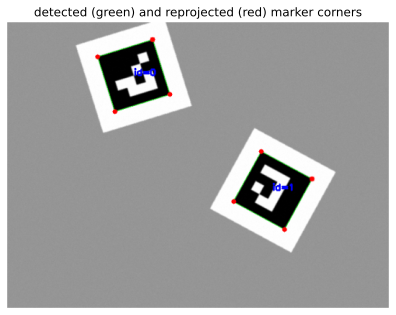

In [13]:
# annotated image: detected marker outlines (green) and reprojected corners (red)
vis = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
det = detect_markers(image)
corners_list = [det[i].reshape(1, 4, 2).astype(np.float32) for i in sorted(det)]
aruco.drawDetectedMarkers(vis, corners_list, np.array(sorted(det)).reshape(-1, 1))
rvec_est, _ = cv2.Rodrigues(R_BC_est.T)
for i in sorted(MARKER_GEOMETRY):
    for pt in project_B(MARKER_GEOMETRY[i], rvec_est, -R_BC_est.T @ t_BC_est):
        cv2.circle(vis, tuple(int(round(v)) for v in pt), 4, (0, 0, 255), -1)
plt.figure(figsize=(6, 4.5)); plt.imshow(vis[..., ::-1]); plt.axis('off'); plt.title('detected (green) and reprojected (red) marker corners'); plt.tight_layout()

---
# Task B: Robust HSV-based cube detection
**Goal:** keep detecting cubes when the light changes, ignore noise, and stop reporting cubes that have disappeared.

## Synthetic frames
The generator draws four coloured cubes on a grey table, with controls for brightness, a shadow band, glare, a thin reflection stripe across one cube, and a thin cable attached to another.
Ground-truth centres are known, so the detectors can be scored: **TP** = cube found within 6 px, **FN** = missed, **FP** = wrong or extra detection.

In [14]:
from lab9_synthetic import make_scene, hsv_to_bgr, HUE, CUBES, score    # test bench: synthetic frames and the TP/FN/FP scoring

demo_img, demo_truth = make_scene(stripe=True)
print('cubes:', demo_truth)

cubes: [('red', 180, 150), ('yellow', 330, 160), ('green', 450, 300), ('blue', 200, 330)]


## Step 1: The original thresholds
The original detector from `vision.py`, re-implemented as a function (same ranges and same square test):

In [15]:
ORIGINAL_RANGES = {
    "red":    [((0, 100, 100), (15, 255, 255)), ((170, 100, 100), (200, 255, 255))],     # 200 > 179: not a valid hue
    "yellow": [((16, 100, 100), (55, 255, 255))],
    "green":  [((56, 100, 100), (80, 255, 255))],
    "blue":   [((81, 200, 200), (110, 255, 255))],                                      # S >= 200 and V >= 200: very strict
}

def square_candidates(mask, min_side=50, max_side=150, min_ratio=0.75, min_fill=0.0, workspace=None):
    """Contours of `mask` that look like a square: rotated-rectangle sides 50..150 px, aspect ratio >= 0.75 (and more, if asked)."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    found = []
    for c in contours:
        (cx, cy), (w, h), angle = cv2.minAreaRect(c)
        if w == 0 or h == 0 or not (min_side <= w <= max_side and min_side <= h <= max_side):
            continue
        ratio = min(w, h) / max(w, h)
        if ratio < min_ratio:
            continue
        if min_fill and cv2.contourArea(c) / (w * h) < min_fill:                # how much of its bounding rectangle the blob fills
            continue
        if workspace is not None and cv2.pointPolygonTest(workspace, (float(cx), float(cy)), False) < 0:
            continue
        found.append((ratio, cx, cy, angle))
    return found

def detect(img, ranges, opening=0, closing=0, **filters):
    """Return {colour: (cx, cy)} for the most square candidate of every colour, in THIS frame only."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    result = {}                                                                # new dictionary every frame: no stale detections
    for name, rs in ranges.items():
        mask = np.zeros(hsv.shape[:2], np.uint8)
        for lo, hi in rs:
            mask = cv2.bitwise_or(mask, cv2.inRange(hsv, np.array(lo), np.array(hi)))
        if opening:
            mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (opening, opening)))
        if closing:
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (closing, closing)))
        candidates = square_candidates(mask, **filters)
        if candidates:
            _, cx, cy, _ = max(candidates)                                     # largest aspect ratio = most square
            result[name] = (cx, cy)
    return result

original = lambda img: detect(img, ORIGINAL_RANGES)
for b in (1.0, 0.6, 0.4):
    im, tr = make_scene(brightness=b)
    print(f'brightness {b}: original detects {sorted(original(im))}  (truth {sorted(t[0] for t in tr)})')

brightness 1.0: original detects ['blue', 'green', 'red', 'yellow']  (truth ['blue', 'green', 'red', 'yellow'])
brightness 0.6: original detects ['green', 'red', 'yellow']  (truth ['blue', 'green', 'red', 'yellow'])
brightness 0.4: original detects []  (truth ['blue', 'green', 'red', 'yellow'])


**How it works / step 1: inspect and calibrate**
- The mouse HSV overlay of the vision window shows H, S, V under the cursor: measure **cube surfaces** (several points, also the dark and bright sides) and **background** (table, shadow), then choose ranges that contain the first and exclude the second.
- The result above shows the fixed thresholds' weakness: at brightness 1.0 all four cubes are found, at 0.6 the **blue** cube disappears (its `V ≥ 200` is not met any more: the cube's V is 126) and at 0.4 **all** cubes vanish (`V ≥ 100`).
- **OpenCV's hue range is 0–179** (8-bit images), so the red interval `(170 … 200)` is invalid above 179: it must be `(172 … 179)`. Red needs two intervals because its hue wraps around 0.
- Improved thresholds (chosen from the measurements, wider V range for dim light, no absurd blue limit): `S ≥ 100`, `V ≥ 50`, hue ranges red 0–8 and 172–179, yellow 20–35, green 50–80, blue 90–115.

In [16]:
IMPROVED_RANGES = {
    "red":    [((0, 100, 50), (8, 255, 255)), ((172, 100, 50), (179, 255, 255))],
    "yellow": [((20, 100, 50), (35, 255, 255))],
    "green":  [((50, 100, 50), (80, 255, 255))],
    "blue":   [((90, 100, 50), (115, 255, 255))],
}
improved_thresholds_only = lambda img: detect(img, IMPROVED_RANGES)
improved = lambda img: detect(img, IMPROVED_RANGES, opening=7, closing=7, min_fill=0.85)

scenarios = {
    'bright':        dict(brightness=1.0),
    'dim (0.6)':     dict(brightness=0.6),
    'dark (0.4)':    dict(brightness=0.4),
    'shadow band':   dict(shadow=True),
    'glare':         dict(glare=True),
    'stripe on cube': dict(stripe=True),
    'cable on cube': dict(cable=True),
}
print(f"{'scenario':15s} {'original TP/FN/FP':>19s} {'new thresholds only':>20s} {'thresholds + morphology + fill':>31s}")
for label, kw in scenarios.items():
    tot = {n: np.zeros(3, int) for n in ('o', 't', 'i')}
    for seed in range(6):
        im, tr = make_scene(seed=seed, **kw)
        for n, fn in (('o', original), ('t', improved_thresholds_only), ('i', improved)):
            tot[n] += score(fn(im), tr)
    print(f"{label:15s} {str(tot['o'].tolist()):>19s} {str(tot['t'].tolist()):>20s} {str(tot['i'].tolist()):>31s}")

scenario          original TP/FN/FP  new thresholds only  thresholds + morphology + fill


bright                   [24, 0, 0]           [24, 0, 0]                      [24, 0, 0]


dim (0.6)                [18, 6, 0]           [24, 0, 0]                      [24, 0, 0]


dark (0.4)               [0, 24, 0]           [24, 0, 0]                      [24, 0, 0]


shadow band             [12, 12, 0]           [24, 0, 0]                      [24, 0, 0]


glare                    [24, 0, 0]           [24, 0, 0]                      [24, 0, 0]


stripe on cube           [18, 6, 0]           [18, 6, 0]                      [24, 0, 0]


cable on cube            [18, 6, 0]           [18, 6, 0]                      [24, 0, 0]


**Results (6 frames per row, 4 cubes each = 24 possible detections)**
- **Lighting and shadow** (dim, dark, shadow): the original loses cubes (or all of them); the new thresholds fix that alone.
- **Stripe** and **cable**: these are structural problems that thresholds cannot fix, they need the **morphology**. A thin stripe cuts the yellow cube's mask into pieces that fail the square test; a thin
  cable makes the green blob elongated. Both are cured by the mask cleanup.
- Nothing produces false positives (FP = 0): the size filter already rejects the isolated pixels and the small red distractor.

## Step 2: Clean each binary mask
- **Opening** (erode, then dilate) removes foreground structures **smaller than the structuring element**: isolated pixels, thin cables. **Closing** (dilate, then erode) fills **gaps and holes** smaller than the element: stripes, reflections.
- **Element and size:** an ellipse (`MORPH_ELLIPSE`) does not favour the image axes. 7×7 px is larger than the widest thing to remove (the 3–4 px cable and stripe) and much smaller than a cube (≈ 60 px), so the
  centre and the size of the cube are preserved; the corners are rounded by about 3 px, which does not move the centre of the rectangle. Larger elements would round the cube more and eat small objects.
- Below: masks of the yellow cube (stripe) for each stage.

raw candidates: []
cleaned candidates: [(330, 159, 1.0)]


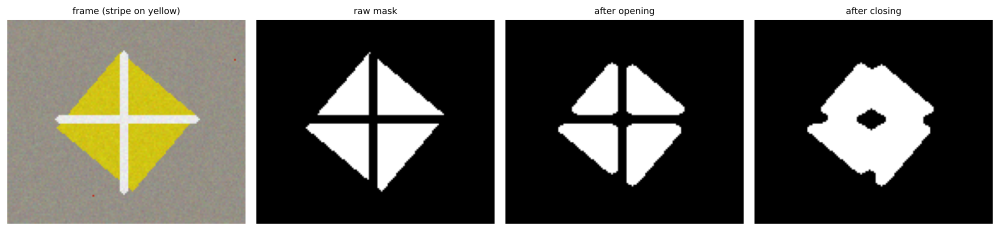

In [17]:
im, tr = make_scene(stripe=True)
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
raw = cv2.inRange(hsv, np.array(IMPROVED_RANGES['yellow'][0][0]), np.array(IMPROVED_RANGES['yellow'][0][1]))
opened = cv2.morphologyEx(raw, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
cleaned = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7)))
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, (title, m) in zip(axes, (('frame (stripe on yellow)', im[..., ::-1]), ('raw mask', raw), ('after opening', opened), ('after closing', cleaned))):
    ax.imshow(m[100:220, 260:400], cmap='gray' if m.ndim == 2 else None); ax.set_title(title, fontsize=9); ax.axis('off')
plt.tight_layout()
for label, m in (('raw', raw), ('cleaned', cleaned)):
    print(label, 'candidates:', [(round(c[1]), round(c[2]), round(c[0], 2)) for c in square_candidates(m)])

**Reading the four panels:** the raw mask is cut into four pieces by the stripes (each fails the square test); opening removes the sharp tips and the isolated red pixels; closing bridges the 3–4 px gaps so the cube is one blob again.
A small hole remains where the two stripes cross. That is harmless: `findContours(..., RETR_EXTERNAL, ...)` only follows the **outer** boundary, and `contourArea` of the outer contour includes the hole, so the fill test still passes.

## Step 3: Reject unreliable candidates
Extra checks in the contour loop, on top of the size and aspect-ratio tests:
- **Area / fill ratio** `contourArea / (w·h)` of the rotated rectangle: a real cube face fills ≥ 85 % of it; a ragged blob, an L-shape or a cube with a cable does not. (Used above with `min_fill=0.85`.)
- **Workspace**: `cv2.pointPolygonTest(polygon, (cx, cy), False) >= 0` keeps only centres inside the valid region: reflections on the base plate, or objects outside the table, are ignored.
- Keep the existing 50–150 px side limits (4 cm cube at this camera distance).

```python
workspace_polygon = np.array([[60, 40], [600, 40], [600, 440], [60, 440]], np.int32).reshape(-1, 1, 2)
im, tr = make_scene(seed=3)
cv2.rectangle(im, (20, 390), (80, 450), hsv_to_bgr(HUE['blue'], 230, 200), -1)                # a blue "cube" outside the workspace (on the frame of the table)
print('without workspace test:', sorted(detect(im, IMPROVED_RANGES, opening=7, closing=7, min_fill=0.85).items()))
print('with workspace test   :', sorted(detect(im, IMPROVED_RANGES, opening=7, closing=7, min_fill=0.85, workspace=workspace_polygon).items()))
```

Output:
```text
without workspace test: [('blue', (50.0, 420.0)), ('green', (449.50445556640625, 299.51226806640625)), ('red', (179.50448608398438, 149.48265075683594)), ('yellow', (329.5098571777344, 159.48826599121094))]
with workspace test   : [('blue', (199.50680541992188, 329.4853210449219)), ('green', (449.50445556640625, 299.51226806640625)), ('red', (179.50448608398438, 149.48265075683594)), ('yellow', (329.5098571777344, 159.48826599121094))]
```


- Without the polygon test the blue object at the image border replaces the real blue cube (it is the more square candidate); with it, the real cube is found again.

## Step 4: Prevent stale detections
The original node keeps `self.detected_cubes` between frames and only ever **adds** to it. The fix is state management, not image processing: build a **new dictionary for every processed frame** and assign it at the end.
Below the node logic is simulated with two versions and a frame sequence in which the red cube is removed.

```python
class NodeOriginal:
    def __init__(self):
        self.detected_cubes = {}
    def on_image(self, img):
        for name, pos in original(img).items():        # only ADDS/overwrites: nothing is ever removed
            self.detected_cubes[name] = pos
    def send_cube_coords(self, color):
        return self.detected_cubes.get(color)          # None means "not detected"

class NodeFixed:
    def __init__(self):
        self.detected_cubes = {}
    def on_image(self, img):
        current = improved(img)                        # a colour is reported only if a valid cube was found in THIS frame
        self.detected_cubes = current                  # replace the dictionary after all colours were examined
    def send_cube_coords(self, color):
        return self.detected_cubes.get(color)

frame1, _ = make_scene(seed=0)
frame2, _ = make_scene(cubes=[c for c in CUBES if c[0] != 'red'], seed=1)                     # the red cube was removed
for name, node in (('original', NodeOriginal()), ('fixed', NodeFixed())):
    node.on_image(frame1); before = node.send_cube_coords('red')
    node.on_image(frame2); after = node.send_cube_coords('red')
    print(f'{name:9s} red before removal: {None if before is None else tuple(round(v) for v in before)}   after removal: {None if after is None else tuple(round(v) for v in after)}')
```

Output:
```text
original  red before removal: (180, 149)   after removal: (180, 149)
fixed     red before removal: (180, 149)   after removal: None
```


- The original node still reports the removed red cube at its old position, and the robot would try to pick nothing. The fixed node returns `None`, so the service answers "not detected".
  In `vision.py` the change is: create `detected = {}` at the start of the callback, fill it inside the colour loop, then `self.detected_cubes = detected` after the loop (and only when the image was processed successfully).
- `send_cube_coords` must then still produce its existing "not detected" response (see Task E for a cleaner one than six 1.0 values).

**Evaluation for the report:** several positions/orientations, at least two lighting conditions, cases with shadow/reflection, and a removed cube; show the original and improved masks; state false detections and misses; justify the thresholds and the 7×7 element.

**Where this goes: `mycobot_vision/vision.py`, `img_callback()`**
```python
detected = {}                                                    # 4. new dictionary for every frame (top of the callback)
...
for color_name, color_data in colors.items():
    mask = ...                                                   # the existing inRange / bitwise_or part
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))     # 2. clean the mask BEFORE findContours
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        rect = cv2.minAreaRect(contour); (cx, cy), (w, h), angle = rect
        ...                                                      # the existing size and aspect-ratio tests
        if cv2.contourArea(contour) / (w * h) < 0.85: continue   # 3. fill ratio
        if cv2.pointPolygonTest(WORKSPACE_POLYGON, (cx, cy), False) < 0: continue    # 3. workspace
        valid_squares.append((contour, rect))
    if valid_squares:
        ...
        detected[color_name] = (cx, cy, angle)                   # instead of self.detected_cubes[color_name] = ...
...
self.detected_cubes = detected                                   # after the loop, only for a successfully processed image
```
Also in this function: the red hue interval `(170 … 200)` becomes `(172 … 179)`, the blue `S`/`V` minimum `200` becomes `100` (the PDF text and the package README both say 100), the thresholds follow the table of Step 1, and
`np.int0(box)` becomes `box.astype(int)` (`np.int0` does not exist in NumPy 2). The `colors` dictionary is **inside** `img_callback`, so it is rebuilt for every image: move it to `__init__` once you tune it.


---
# Task C: Interactive calibration of HSV thresholds
**Goal:** a program that derives thresholds from an object the user outlines. The tested core is in `solutions/hsv_calibrator.py`; the mouse/window part is in the same file
(`python hsv_calibrator.py image.png`) and was **not run here** (needs a display). Steps of the program:

1. `cv2.imread` (check for `None`), show the image, collect polygon vertices with a mouse callback (left click adds, right click removes, Enter finishes), draw on a **copy** of the image.
2. `cv2.fillPoly` makes the polygon mask; `cv2.erode` shrinks it so background pixels at the boundary are excluded; `hsv[mask > 0]` extracts the HSV pixels inside.
3. Median and standard deviation of S and V: $[\max(0, \tilde x - 2\sigma),\ \min(255, \tilde x + 2\sigma)]$. ($\sigma$ is the **standard deviation**: the variance has the unit "value²" and cannot be added to a pixel value.)
4. Hue is **circular** (0…179, 179 next to 0): centre from the mean of the unit vectors $e^{i2\pi h/180}$, spread from the wrapped differences $(h - c + 90) \bmod 180 - 90$; an interval crossing 0 or 179 becomes two ranges combined with `cv2.bitwise_or`.
5. `cv2.inRange` on the whole image; show original with polygon, mask and masked image (`cv2.bitwise_and(img, img, mask=mask)`); print a `colors` entry for `vision.py`.

```python
from hsv_calibrator import circular_hue, estimate_thresholds, apply_thresholds, format_for_vision

# why the naive mean fails for a red cube: hues 176..179 and 0..3
hues = np.array([176, 177, 178, 179, 0, 1, 2, 3])
print('naive mean hue:', hues.mean(), '  circular centre / spread: %.2f / %.2f' % circular_hue(hues))
```

Output:
```text
naive mean hue: 89.5   circular centre / spread: 179.50 / 2.29
```


- The naive mean is 89.5 (a cyan-green!), the circular centre is 179.5 (which is the same as −0.5: red, right at the wrap-around), spread about 2.3. This is why hue needs its own treatment.

In [21]:
from hsv_calibrator import circular_hue, estimate_thresholds, apply_thresholds, format_for_vision   # solutions/hsv_calibrator.py
from lab9_synthetic import shaded_cube_scene, iou

img_r, truth_r, poly_r = shaded_cube_scene(hue=1)                          # a red cube: hue wraps around 0
th = estimate_thresholds(img_r, poly_r)
print('hue ranges:', th['hue_ranges'], ' S:', th['S'], ' V:', th['V'], ' (pixels used: %d)' % th['n_pixels'])
print(format_for_vision('red', th))
print('IoU with the true cube region: %.3f' % iou(apply_thresholds(img_r, th), truth_r))

hue ranges: [(0, 11), (170, 179)]  S: (163, 238)  V: (155, 232)  (pixels used: 10232)
"red": {
    "ranges": [
        (np.array([0, 163, 155]), np.array([11, 238, 232])),
        (np.array([170, 163, 155]), np.array([179, 238, 232])),
    ],
},
IoU with the true cube region: 0.867


**How it works**
- For the red cube the estimated hue interval splits into `(0, 11)` and `(170, 179)`: exactly the two ranges of the original red entry. Median ± 2σ for S is 163…238, for V 155…232 (the V range is wide because of the shading gradient).
- The printed text is the `"red": {...}` entry for the `colors` dictionary of `vision.py` (in the node the two interval entries are the `"ranges"` list).
- **IoU** (intersection over union) compares the resulting mask with the true cube region: 1.0 = perfect.

## Evaluation: other lighting, and the interval width

In [22]:
th_bright = estimate_thresholds(img_r, poly_r)
for label, br in (('same lighting', 1.0), ('brighter (x1.15)', 1.15), ('dimmer (x0.6)', 0.6)):
    im, tr, _ = shaded_cube_scene(hue=1, brightness=br, seed=7)
    print(f'{label:18s} thresholds from the bright image: IoU {iou(apply_thresholds(im, th_bright), tr):.3f}', end='')
    th_own = estimate_thresholds(im, poly_r)
    print(f'   recalibrated on this image: IoU {iou(apply_thresholds(im, th_own), tr):.3f}   (V range {th_own["V"]})')

print()
for k in (1.0, 2.0, 3.0):
    print(f'k = {k}: IoU {iou(apply_thresholds(img_r, estimate_thresholds(img_r, poly_r, k=k)), truth_r):.3f}')

same lighting      thresholds from the bright image: IoU 0.868   recalibrated on this image: IoU 0.868   (V range (155, 232))
brighter (x1.15)   thresholds from the bright image: IoU 0.570   recalibrated on this image: IoU 0.891   (V range (180, 255))


dimmer (x0.6)      thresholds from the bright image: IoU 0.000   recalibrated on this image: IoU 0.864   (V range (92, 139))

k = 1.0: IoU 0.293
k = 2.0: IoU 0.867
k = 3.0: IoU 0.997


**Discussion (what to write in the report)**
- **Incorrectly excluded pixels:** with $\tilde x \pm 2\sigma$ each channel keeps only about 95 % of a Gaussian distribution, and a pixel must pass **three** channels at once, so ≈ 14 % of the cube pixels are lost
  (IoU ≈ 0.87). $\pm3\sigma$ gives IoU ≈ 0.997. The V distribution of a shaded surface is not Gaussian either (here it is closer to uniform), which is one more reason for a generous interval.
- **Incorrectly included pixels:** with wide intervals, background pixels with a similar colour (skin, a shadow of the same hue) pass. Erode the polygon to avoid boundary pixels in the calibration, and check the masked image visually.
- **Lighting:** thresholds calibrated in bright light **do not transfer**: at ×0.6 brightness the mask is empty (IoU 0) because V dropped below the interval, and at ×1.15 many pixels leave it. Recalibrating on the new image restores IoU ≈ 0.88.
  So either calibrate per lighting condition, or use a wider V range (lower minimum, as in Task B) and rely on hue and saturation for the colour decision.
- **Minimum width / manual adjustment:** yes. A very uniform region would produce a tiny σ and a razor-thin interval that rejects the next frame's noise; `estimate_thresholds` therefore enforces a minimum width (30 for S/V, ±4 for hue), and the result should be
  checked by eye and adjusted by hand when necessary. Compare with the original fixed thresholds in `vision.py`: the calibrated ones are narrower in S and V (better colour separation) but must be repeated when the light changes.

**Where this goes: nowhere in the node: it is a stand-alone tool.** `solutions/hsv_calibrator.py` (run on any machine with a display and OpenCV):
```bash
python hsv_calibrator.py saved_frame.png --name red      # click the polygon, Enter; prints the entry for the colors dictionary
```
Save a frame from the running system first (for example with `ros2 run mycobot_280pi opencv_camera` and a one-line script, or a screenshot of the debug window), calibrate on one image, test on frames from two other lighting conditions,
and paste the printed `"ranges"` entry into the `colors` dictionary of `vision.py`. The functions it uses are the ones tested above.


---
# Task D: Detecting object colour and shape
**Goal:** distinguish cubes from cylinders (square vs circle in a top view) and support several objects, including of the same colour.

## Step 2: Shape features
For every plausible contour (after the mask cleanup of Task B):
- area $A$ = `cv2.contourArea`, perimeter $P$ = `cv2.arcLength(c, True)`, centre from the image moments $c_x = m_{10}/m_{00},\ c_y = m_{01}/m_{00}$ (`cv2.moments`; check $m_{00} \ne 0$);
- `cv2.minAreaRect`: side lengths ratio, and the **fill ratio** $A/(w\,h)$;
- circularity $C = 4\pi A/P^2$ (a perfect circle: 1, a square: $\pi/4 \approx 0.785$);
- `cv2.approxPolyDP(c, ε·P, True)`: number of vertices (a square ≈ 4, a circle ≈ 8 with $\varepsilon = 3\%$);
- solidity $A / A_{hull}$ (`cv2.convexHull`): 1 for convex shapes, lower for occluded or ragged ones.

**How they separate the shapes**
- The **aspect ratio** alone cannot: a square and a circle both give ratio ≈ 1 (the PDF says so explicitly).
- The **fill ratio** is the most robust: a square fills 100 % of its rotated bounding rectangle, a circle only $\pi/4 = 78.5\,\%$, independent of the rotation.
- **Circularity** is theoretically also good but suffers from the pixel grid: for a rotated square the perimeter measured along a digital contour is longer than the true one (staircase), so $C$ drops from 0.79 to about 0.70 at 20°; it also reacts strongly to noisy boundaries. Treat it as a secondary feature.
- **Vertices** from `approxPolyDP` depend on $\varepsilon$: too small and noise adds vertices, too large and a circle becomes a square.
- **Noise and occlusion** change all of these: a jagged boundary lengthens $P$; a partly hidden object changes the fill, ratio and solidity. That is why an `unknown` label is required.

In [23]:
from lab9_synthetic import draw_shape

def shape_features(mask, min_area=500):
    """Features of the largest contour of a (cleaned) binary mask, or None."""
    k5 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(cv2.morphologyEx(mask, cv2.MORPH_OPEN, k5), cv2.MORPH_CLOSE, k5)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    c = max(contours, key=cv2.contourArea)
    area, perimeter = cv2.contourArea(c), cv2.arcLength(c, True)
    if area < min_area or perimeter <= 0:                                 # too small; also protects the division below
        return None
    m = cv2.moments(c)
    (cx, cy), (w, h), angle = cv2.minAreaRect(c)
    return dict(area=area, perimeter=perimeter, circularity=4 * np.pi * area / perimeter ** 2,
                vertices=len(cv2.approxPolyDP(c, 0.03 * perimeter, True)),
                ratio=min(w, h) / max(w, h), fill=area / (w * h), solidity=area / cv2.contourArea(cv2.convexHull(c)),
                center=(m['m10'] / m['m00'], m['m01'] / m['m00']), angle=angle)

def classify_shape(f):
    """'cube', 'cylinder' or 'unknown' (never forced)."""
    if f is None or f['ratio'] < 0.75 or f['solidity'] < 0.90:
        return 'unknown'
    if f['fill'] > 0.90:
        return 'cube'
    if 0.70 < f['fill'] < 0.83 and f['vertices'] >= 6:
        return 'cylinder'
    return 'unknown'

print(f"{'shape':9s} {'angle':>5s} {'circ.':>6s} {'verts':>5s} {'ratio':>6s} {'fill':>6s} {'solid.':>6s}  ->")
for kind in ('cube', 'cylinder'):
    for ang in (0, 20, 45):
        f = shape_features(draw_shape(kind, 60, ang))
        print(f"{kind:9s} {ang:5d} {f['circularity']:6.3f} {f['vertices']:5d} {f['ratio']:6.3f} {f['fill']:6.3f} {f['solidity']:6.3f}  {classify_shape(f)}")

shape     angle  circ. verts  ratio   fill solid.  ->
cube          0  0.800     4  1.000  0.998  0.999  cube
cube         20  0.701     4  0.998  0.971  0.976  cube
cube         45  0.802     4  0.988  0.986  0.994  cube
cylinder      0  0.892     8  0.967  0.784  0.986  cylinder
cylinder     20  0.892     8  0.967  0.784  0.986  cylinder
cylinder     45  0.892     8  0.967  0.784  0.986  cylinder


**How it works (step 3: classification)**
- Rule set: reject "too elongated or not convex" as `unknown`; fill > 0.90 → **cube**; fill between 0.70 and 0.83 **and** at least 6 polygon vertices → **cylinder**; everything else → **`unknown`**.
  The thresholds come from the geometry (1.0 and π/4) with margins for noise; **on real images they must be re-derived from the actual camera** (perspective and lens distortion turn a circle into a slight ellipse and a square top into a
  slight trapezoid, and the visible side walls of a cube at the image border change the outline).
- The cylinder's fill (0.784) does not change with rotation (a circle has none), while the cube stays above 0.97 at any angle: the rotated-square circularity of 0.70 shows why circularity alone would be unreliable.

**Robustness test: noise and partial occlusion (40 objects each)**

In [24]:
from collections import Counter
confusion = Counter()
for kind in ('cube', 'cylinder'):
    for seed in range(40):
        occluded = seed >= 20
        f = shape_features(draw_shape(kind, 60, (seed * 13) % 90, seed=seed, occlude=0.15 if occluded else 0.0, noise=0.15))
        confusion[(kind, 'occluded' if occluded else 'clean', classify_shape(f))] += 1
print(f"{'true':9s} {'condition':9s} {'cube':>5s} {'cylinder':>9s} {'unknown':>8s}")
for kind in ('cube', 'cylinder'):
    for cond in ('clean', 'occluded'):
        print(f"{kind:9s} {cond:9s} {confusion[(kind, cond, 'cube')]:5d} {confusion[(kind, cond, 'cylinder')]:9d} {confusion[(kind, cond, 'unknown')]:8d}")

true      condition  cube  cylinder  unknown
cube      clean        20         0        0
cube      occluded      3         0       17
cylinder  clean         0        20        0
cylinder  occluded      0         7       13


- Clean objects (with a jagged boundary, 20 each) are all classified correctly. With 15 % of the object hidden, most become **`unknown`**, and **none is mislabelled** as the other shape: this is the intended behaviour, the classifier says "I don't know"
  instead of guessing. A **discussed uncertain case** for the report: a cylinder cut by the image border or covered by the pump tube looks like a square with a rounded corner: fill and solidity fall between the two classes.

## Steps 1, 4: Colour segmentation + shape → a list of detection records
Instead of `{colour: (cx, cy)}` (at most one object per colour) the vision node keeps a **list of records**, rebuilt for every frame:

In [25]:
def detect_objects(img, ranges=IMPROVED_RANGES, min_area=1200):
    """List of detections {color, shape, center, angle, area, features...}: every plausible region of every colour."""
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    k7 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    records = []                                                              # new list for every frame: removed objects disappear
    for color, rs in ranges.items():
        mask = np.zeros(hsv.shape[:2], np.uint8)
        for lo, hi in rs:
            mask = cv2.bitwise_or(mask, cv2.inRange(hsv, np.array(lo), np.array(hi)))
        mask = cv2.morphologyEx(cv2.morphologyEx(mask, cv2.MORPH_OPEN, k7), cv2.MORPH_CLOSE, k7)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:                                                    # EVERY contour, not only the best one
            if cv2.contourArea(c) < min_area:
                continue
            single = np.zeros_like(mask); cv2.drawContours(single, [c], -1, 255, -1)
            f = shape_features(single, min_area)
            if f is None:
                continue
            records.append(dict(color=color, shape=classify_shape(f), center=f['center'],
                                angle=f['angle'] if classify_shape(f) == 'cube' else None,     # a cylinder top has no visible rotation
                                area=f['area'], fill=round(f['fill'], 3)))
    return records

shape_img = syn.scene_shapes()
records = detect_objects(shape_img)
for r in sorted(records, key=lambda r: (r['color'], r['center'][0])):
    print(f"{r['color']:7s} {r['shape']:9s} centre ({r['center'][0]:5.1f}, {r['center'][1]:5.1f})  angle {r['angle'] if r['angle'] is None else round(r['angle'], 1)}  fill {r['fill']}")

blue    cylinder  centre (350.0, 330.0)  angle None  fill 0.785
green   cube      centre (179.5, 319.5)  angle 25.7  fill 0.97
red     cylinder  centre (150.0, 130.0)  angle None  fill 0.785
red     cylinder  centre (300.0, 130.0)  angle None  fill 0.785
red     cube      centre (469.5, 119.5)  angle 25.7  fill 0.97
yellow  cube      centre (499.5, 329.5)  angle 25.7  fill 0.97


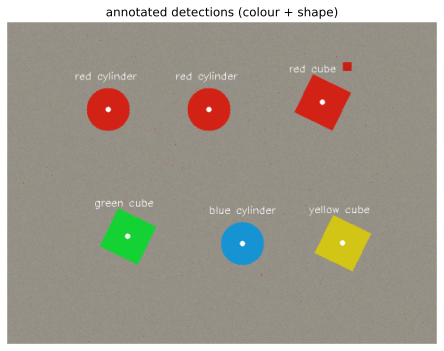

In [26]:
vis = shape_img.copy()
for r in records:
    cx, cy = int(r['center'][0]), int(r['center'][1])
    cv2.circle(vis, (cx, cy), 4, (255, 255, 255), -1)
    cv2.putText(vis, f"{r['color']} {r['shape']}", (cx - 50, cy - 45), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
plt.figure(figsize=(7, 5)); plt.imshow(vis[..., ::-1]); plt.axis('off'); plt.title('annotated detections (colour + shape)'); plt.tight_layout()

**How it works**
- Every contour of every colour mask above the area limit becomes a **record** (a dictionary). Several objects of the same colour are now possible (the two red cylinders). `records` is a **new list for each frame**: an object that is removed simply does not appear next time (stale-data problem solved).
- The image angle is stored **only for cubes**: the top of an unmarked cylinder is circular, its rotation about the vertical axis is not observable in a top view.
- `np.zeros_like(mask)` makes an empty mask of the same size and type; `cv2.drawContours(..., -1, 255, -1)` fills one contour so the features are computed for that region alone.
- The debug window overlay in the node would use `cv2.drawContours`, `cv2.circle` and `cv2.putText` exactly as above.
- **Evaluation for the report:** cubes and cylinders of several colours, two of the same colour, annotated image, the query tests of Task E (present, absent, several matches), and one uncertain case.

**Where this goes: `mycobot_vision/vision.py`, `img_callback()` and `send_cube_coords()`**
- The per-colour contour loop (rectangle test, "one cube per colour") is replaced by `detect_objects(img)`; its result list is stored as `self.detected_objects = records` (a new list for every frame).
- `shape_features` and `classify_shape` become methods or module-level functions of `vision.py`; their thresholds (`fill > 0.90`, `0.70…0.83`, vertices ≥ 6, solidity ≥ 0.90) **must be re-derived on real frames**: they come from the geometry (1.0 and π/4) with margins, not from your camera.
- `send_cube_coords` then answers from `self.detected_objects` by colour **and** shape (Task E defines the service fields).
- The debug window draws the records as in the annotated image above (`cv2.circle`, `cv2.putText`).


---
# Task E: Extension of the object interface (colour + shape, identities)
**Goal:** select objects by colour **and** shape, replace the "six 1.0" sentinel by an explicit flag, keep a unique ID from detection through pick, attach and release, and simplify the menu.

## 1. The service definition
Current `GetCubeCoords.srv`: request `string color`; response `float64[] coords`. New version (file name and type can stay if the dependent code is updated; a better name would be `GetObject.srv`):
```
# request
string color          # "red", "yellow", "green", "blue"
string shape          # "cube", "cylinder" (empty string = any shape)
---
# response
bool found            # False if no object matches (replaces the special [1,1,1,1,1,1] array)
string object_id      # unique id of the selected object, e.g. "red_cylinder_2"
string color
string shape
geometry_msgs/Pose pose      # frame g_base, metres; position = centre of the TOP FACE, orientation from yaw
string[] match_ids    # ids of ALL matching objects (so the client can let the user choose)
geometry_msgs/Point[] match_positions
```
**Selection rule:** if several objects match, the response contains the one **closest to the robot base** (or the largest, document the rule) in `pose`/`object_id`, and **all** matches in `match_ids`/`match_positions` so `choose_pick` can ask the user.
If none matches: `found = False` and empty lists. After changing the `.srv`: `colcon build --packages-select mycobot_interfaces`, then rebuild the dependents (`mycobot_vision`, `mycobot_brain`), `source install/setup.bash`, and restart **both** nodes (a stale interface version gives confusing errors).

## 2. Server side: stable IDs and matching
IDs must stay the same for the same physical object from frame to frame (the planning scene refers to them). A simple tracker: assign each new detection the ID of the nearest previous detection of the same colour and shape within a
distance limit, otherwise a new ID.

In [27]:
class ObjectRegistry:
    """Keeps unique ids stable over frames: nearest previous object of the same colour+shape within `max_dist` pixels keeps its id."""
    def __init__(self, max_dist=25.0):
        self.max_dist = max_dist
        self.counter = {}
        self.objects = []                                  # current frame: dicts with id, color, shape, center, angle

    def update(self, records):
        previous, new_objects = self.objects, []
        for r in records:
            best, best_d = None, self.max_dist
            for p in previous:
                if p['color'] == r['color'] and p['shape'] == r['shape']:
                    d = np.hypot(p['center'][0] - r['center'][0], p['center'][1] - r['center'][1])
                    if d <= best_d and all(p['id'] != q['id'] for q in new_objects):
                        best, best_d = p, d
            if best is not None:
                oid = best['id']
            else:
                key = (r['color'], r['shape'])
                self.counter[key] = self.counter.get(key, 0) + 1
                oid = f"{r['color']}_{r['shape']}_{self.counter[key]}"
            new_objects.append({**r, 'id': oid})
        self.objects = new_objects                         # objects that vanished are dropped
        return self.objects

    def query(self, color, shape='', base=(0.0, 0.0)):
        """Service logic: found flag, the selected match (closest to `base`) and all matches. shape '' means any shape."""
        matches = [o for o in self.objects if o['color'] == color and (shape in ('', o['shape']))]
        matches.sort(key=lambda o: np.hypot(o['center'][0] - base[0], o['center'][1] - base[1]))
        return {'found': bool(matches), 'selected': matches[0] if matches else None, 'matches': matches}

registry = ObjectRegistry()
frame1 = registry.update(detect_objects(shape_img))
print('ids frame 1:', [(o['id'], tuple(round(v) for v in o['center'])) for o in frame1])
# frame 2: slightly different positions (noise), one red cylinder removed
records2 = [r for r in detect_objects(shape_img) if not (r['color'] == 'red' and r['shape'] == 'cylinder' and r['center'][0] > 250)]
for r in records2: r['center'] = (r['center'][0] + 1.5, r['center'][1] - 1.0)
frame2 = registry.update(records2)
print('ids frame 2:', [o['id'] for o in frame2], ' (red_cylinder_1 is gone, the others kept their ids)')

ids frame 1: [('red_cylinder_1', (300, 130)), ('red_cylinder_2', (150, 130)), ('red_cube_1', (470, 119)), ('yellow_cube_1', (500, 329)), ('green_cube_1', (180, 319)), ('blue_cylinder_1', (350, 330))]
ids frame 2: ['red_cylinder_2', 'red_cube_1', 'yellow_cube_1', 'green_cube_1', 'blue_cylinder_1']  (red_cylinder_1 is gone, the others kept their ids)


```python
def show_query(color, shape):
    r = registry.query(color, shape, base=(320, 480))
    if not r['found']:
        print(f"query ({color!r}, {shape!r}): found = False")
    else:
        print(f"query ({color!r}, {shape!r}): found = True, selected {r['selected']['id']}, matches {[m['id'] for m in r['matches']]}")

registry.update(detect_objects(shape_img))         # back to the full scene
show_query('red', 'cylinder')                      # existing object, two matches
show_query('red', 'cube')                          # must NOT return a red cylinder
show_query('blue', 'cube')                         # absent
show_query('red', '')                              # any shape: three red objects
```

Output:
```text
query ('red', 'cylinder'): found = True, selected red_cylinder_3, matches ['red_cylinder_3', 'red_cylinder_2']
query ('red', 'cube'): found = True, selected red_cube_1, matches ['red_cube_1']
query ('blue', 'cube'): found = False
query ('red', ''): found = True, selected red_cylinder_3, matches ['red_cylinder_3', 'red_cylinder_2', 'red_cube_1']
```


**How it works**
- **Identity over time:** in frame 2 the removed cylinder disappears and the others keep their ids. When the cylinder is put back later (the query cell updates with the full scene again) it gets a **new** id, `red_cylinder_3`:
  the registry has no memory of vanished objects. A real system could keep ids for a few seconds (to bridge a missed detection) and should only drop them after the object has been absent for several frames.
- `{**r, 'id': oid}` copies the record dictionary and adds the id. `registry.objects` is replaced in every frame: vanished objects are dropped, unchanged ones keep their id. (In the real node `update` is called from the image callback and
  `query` from the service callback.)
- A request for **red cylinder** returns the cylinders only and lists both matches; **red cube** returns only the cube; the absent **blue cube** returns `found = False`; an empty shape means "any": the three red objects.
- The registry works in **pixel** coordinates here; the conversion to robot coordinates (Task A) is applied to the selected object's centre before the response is filled.

## 3. Client side (`brain.py`)
```python
def get_object(self, color, shape):
    request = GetObject.Request()
    request.color, request.shape = color, shape
    future = self.object_client.call_async(request)
    rclpy.spin_until_future_complete(self, future)
    response = future.result()
    if not response.found:
        self.get_logger().warn(f"no {color} {shape} detected")
        return None
    return {'id': response.object_id, 'color': response.color, 'shape': response.shape, 'pose': response.pose,
            'matches': list(zip(response.match_ids, response.match_positions))}
```
`spin_until_future_complete` waits (spinning the node) until the asynchronous service call has an answer. The **dictionary** carries the identity and pose together through the manipulation
functions, instead of a bare colour string.

## 4. MoveIt: box or cylinder, unique id
```python
def spawn_object(self, obj):                       # replaces spawn_cube(color)
    co = CollisionObject()
    co.id = obj['id']                              # unique id, NOT the colour
    co.header.frame_id = "g_base"
    co.operation = CollisionObject.ADD
    shape = SolidPrimitive()
    if obj['shape'] == 'cube':
        shape.type = SolidPrimitive.BOX
        shape.dimensions = [CUBE_SIZE, CUBE_SIZE, CUBE_SIZE]                 # x, y, z side lengths
    else:
        shape.type = SolidPrimitive.CYLINDER
        shape.dimensions = [CYLINDER_HEIGHT, CYLINDER_RADIUS]                # height, RADIUS (not diameter)
    co.primitives.append(shape)
    co.primitive_poses.append(centre_pose)                                   # centre of the solid, z = height / 2 above the table
    self.cube_publisher.publish(co)
    self.attach_object(obj['id'], "env_table")
```
- `SolidPrimitive.BOX` uses three dimensions, `SolidPrimitive.CYLINDER` uses **[height, radius]**: a diameter passed as a radius doubles the cylinder in the planning scene.
- The **same** `id` must be used for `ADD` (spawn), `AttachedCollisionObject.object.id` (attach/detach) and `REMOVE` (destroy): otherwise the scene holds ghost objects or the pump collides with an object that should be attached to it.
  The `touch_links` list in `attach_cube` currently contains the four colour names as link names; it needs the new ids (or a different scheme).
- `pick(obj)` and `drop(obj, coords)` receive the object dictionary; `place()` currently adds a fixed `0.04 * number` for the stack height: a cylinder has a different height, so use the object's own height.
- (Not run here: the `moveit_msgs` package is not installed on this laptop.) The shape parameters can still be prepared and checked as plain data:

In [29]:
CUBE_SIZE, CYLINDER_HEIGHT, CYLINDER_RADIUS = 0.04, 0.05, 0.02       # metres: CALIBRATE these on the real objects

def primitive_for(shape):
    if shape == 'cube':
        return 'BOX', [CUBE_SIZE, CUBE_SIZE, CUBE_SIZE]
    if shape == 'cylinder':
        return 'CYLINDER', [CYLINDER_HEIGHT, CYLINDER_RADIUS]           # radius, not diameter
    raise ValueError(f'unsupported shape {shape!r}')

for s in ('cube', 'cylinder'):
    print(s, primitive_for(s), ' centre height above the table:', (CUBE_SIZE if s == 'cube' else CYLINDER_HEIGHT) / 2)
try:
    primitive_for('unknown')
except ValueError as e:
    print('rejected:', e)

cube ('BOX', [0.04, 0.04, 0.04])  centre height above the table: 0.02
cylinder ('CYLINDER', [0.05, 0.02])  centre height above the table: 0.025
rejected: unsupported shape 'unknown'


## 5. Simplified menu control flow
The current `choose_pick()` / `choose_drop()` / `control_menu()` call themselves after every choice. Each call adds a stack frame that is never released (and a long session eventually hits Python's recursion limit); "exit" only adds another
`control_menu()` call. Replace the recursion by loops with `break`/`return`. The input function is passed in, so the logic can be tested with scripted answers.

In [30]:
COLORS = {'r': 'red', 'y': 'yellow', 'g': 'green', 'b': 'blue'}
SHAPES = {'c': 'cube', 'cube': 'cube', 'y': 'cylinder', 'cyl': 'cylinder', 'cylinder': 'cylinder'}
BINS = {'a': 'A', 'b': 'B', 'c': 'C', 'd': 'D'}

def normalise(text, table):
    """Single validation step: abbreviation or full word -> full name, else None."""
    text = text.strip().lower()
    return table.get(text) or (text if text in table.values() else None)

def choose_pick(registry, input_fn=input, log=print):
    """Ask for colour and shape, and (if several objects match) which one. Returns the chosen object, or None for 'exit'."""
    while True:                                                    # a loop instead of self.choose_pick()
        color = input_fn("Color: red (r) / yellow (y) / green (g) / blue (b), or exit\n")
        if color.strip().lower() == 'exit':
            return None
        color = normalise(color, COLORS)
        if color is None:
            log('Invalid colour!'); continue
        shape = input_fn("Shape: cube (c) / cylinder (y)\n")
        if shape.strip().lower() == 'exit':
            return None
        shape = normalise(shape, SHAPES)
        if shape is None:
            log('Invalid shape!'); continue
        result = registry.query(color, shape)
        if not result['found']:
            log(f'No {color} {shape} detected.'); continue
        matches = result['matches']
        if len(matches) == 1:
            return matches[0]
        log('Matching objects:')
        for i, o in enumerate(matches, 1):
            log(f"{i} - {o['id']} at ({o['center'][0]:.0f}, {o['center'][1]:.0f})")
        while True:                                                # second loop: the selection among several matches
            answer = input_fn('Select object: ').strip().lower()
            if answer == 'exit':
                return None
            if answer.isdigit() and 1 <= int(answer) <= len(matches):
                return matches[int(answer) - 1]
            log('Invalid choice!')

script = iter(['x', 'red', 'q', 'blue', 'cube', 'r', 'y', '7', '2'])       # scripted answers: bad colour; red + bad shape; blue cube (absent); r + y (two matches); bad choice 7; choice 2
lines = []
answers = lambda prompt: (lines.append(prompt.strip().split('\n')[0] + '  ->  ' + (a := next(script))), a)[1]
chosen = choose_pick(registry, input_fn=answers, log=lambda s: lines.append('    ' + s))
print('\n'.join(lines))
print('chosen object:', chosen['id'])

Color: red (r) / yellow (y) / green (g) / blue (b), or exit  ->  x
    Invalid colour!
Color: red (r) / yellow (y) / green (g) / blue (b), or exit  ->  red
Shape: cube (c) / cylinder (y)  ->  q
    Invalid shape!
Color: red (r) / yellow (y) / green (g) / blue (b), or exit  ->  blue
Shape: cube (c) / cylinder (y)  ->  cube
    No blue cube detected.
Color: red (r) / yellow (y) / green (g) / blue (b), or exit  ->  r
Shape: cube (c) / cylinder (y)  ->  y
    Matching objects:
    1 - red_cylinder_2 at (150, 130)
    2 - red_cylinder_3 at (300, 130)
Select object:  ->  7
    Invalid choice!
Select object:  ->  2
chosen object: red_cylinder_3


**How it works**
- `normalise` is the **single validation step**: a lookup in a table of abbreviations, returning the full name or `None`. No chain of `if color in [...]` per colour.
- `while True: ... continue / return`: invalid input repeats the question; a valid path returns. The function returns `None` on "exit", the caller (`control_menu`) then `break`s out of its own loop: no nested calls.
- The scripted run shows the paths in order: bad colour `x` → "Invalid colour" and ask again; `red` then bad shape `q` → "Invalid shape" (the loop starts again at the colour question); `blue` + `cube` → "No blue cube detected"; `r` + `y` (abbreviations) → the two matching red
  cylinders are listed with their ids; the choice `7` is refused, `2` is accepted and its object returned.
- `answers` is a small function that logs each prompt with the scripted answer (the walrus operator `:=` assigns inside the expression); in the real node `input_fn` is Python's `input`.
- **Destination bins** stay in `choose_drop()`, also as a loop with `normalise(text, BINS)`.
- Top-level menu: `while True: mode = input(...)`; `"exit"` → `break`; each mode returns to the loop.

## What to document for Task E (deliverable)
The updated `.srv`, server callback, `get_object`, `spawn_object` (box and cylinder), object ids through `pick`/`drop`, the loop-based menu, and a test log: request an existing object, an absent one, and one with several matches; a physical run with a cylinder; comparison with the original behaviour (two red objects,
cylinder vs cube).

**Where this goes: three packages, with a build order**
| file | change |
|---|---|
| `mycobot_interfaces/srv/GetCubeCoords.srv` (or a new `GetObject.srv`) | the request/response above; remember to add new files to `CMakeLists.txt` |
| `mycobot_vision/vision.py` | `ObjectRegistry` inside the node; `create_service` callback answers `query(color, shape)` and converts the selected centre with `pixel_to_base` (Task A) |
| `mycobot_brain/brain.py` | `get_object`, `spawn_object`, `attach_object`, `destroy_object`, `pick(obj)`, `drop(obj, coords)`, `place`, the loop-based menu |

Build and restart order (on every machine that runs one of these nodes):
```bash
cd ~/mycobot-project/pp_moveit_ws
colcon build --symlink-install --packages-select mycobot_interfaces       # regenerates the Python classes
colcon build --symlink-install --packages-select mycobot_vision mycobot_brain
source install/setup.bash                                                # in EVERY terminal, then restart vision AND brain
```
A node that was started before the rebuild keeps the old interface and produces confusing errors.


---
# Summary and how to use this in the lab
- **Exploration first**, with the checklist and data flow of Part 0; note which of the 14 code problems you actually observe.
- **Pick two tasks.** The two with the least dependency on the others: **A (calibration)** and **C (HSV calibrator)** are self-contained, **B** and **D** improve the same file (`vision.py`, merge carefully), **E** touches brain, vision and the interface package (build order!).
- **Evaluate on the real system** with independent measurements (positions with a ruler, several lighting conditions); this notebook gives the expected *shape* of the results, not your numbers.
- Safety as always: supervised first motions, workspace clear, never both the simulation and the Controller, and a person triggers every motion.

| quantity | what to check |
|---|---|
| calibration | reprojection error (px), estimated height vs measured, position error at independent points (mm), repeatability |
| HSV | false detections, missed cubes, stale detections, under ≥ 2 lightings |
| shapes | labels, `unknown` cases, two objects of one colour |
| interface | found flag, ids, multiple matches, id consistency through pick/attach/drop |
- **Running the real system** (machines, files, start order, SSH commands for the lab day, values to experiment with): `Lab8_Lab9_run_guide.md`.
